## Q11

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [206]:
np.random.seed(42)

In [205]:
''' 
    Set Up for Simulation 1 (psi is a particular value)

'''
# Simulation parameters
r = 0
mu = 0
S0 = 100
B0 = 1
sigma = 0.20
theta_0 = 30
b_0 = 0
b = -100
beta = 0.28
alpha = 0.5
phi = 1
gamma = 0.2
zeta = 0.25
w0 = 10

#Time
dt = 8 / (365 * 24 * 1)  # daily
T = 1  # total time in years
N = int(T / dt) 
M = 3  # number of paths
quarter_len = int(0.25 / dt)  # 每季度步数
opex_indices = [0, quarter_len, 2 * quarter_len, 3 * quarter_len, N]

#Parameters to Change
psi = 3





In [206]:
''' 
    Calculation Functions 
'''
    
def bs_put_price(S, K, T, sigma, r=0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    except ZeroDivisionError:

        return 0.0
    
def bs_call_price(S, K, T, sigma, r =0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    except ZeroDivisionError:
        return 0.0
    
def bs_delta(S, K, T, sigma, option_type='call', r=0):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1
    


def bs_gamma(S, K, T, sigma, r=0):
    """
    Black–Scholes Gamma: ∂²C/∂S²
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    # gamma formula
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_charm(S, K, T, sigma, r=0):
    """
    Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
    For r=0 simplifies to: -φ(d1)*d2/(2*T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1, d2
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    # charm formula
    return -norm.pdf(d1) * d2 / (2 * T)

def bs_speed(S, K, T, sigma, r=0):
    """
    Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
    Simplified finite formula:
      ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    pdf_d1 = norm.pdf(d1)
    term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
    term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
    return term1 + term2

In [127]:
def dDeltaCalc(S_t, sigma, K, T):

    def bs_delta(S, K, T, sigma, option_type='call', r=0):
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        if option_type == 'call':
            return norm.cdf(d1)
        else:
            return norm.cdf(d1) - 1
    
    def bs_gamma(S, K, T, sigma, r=0):
        """
        Black–Scholes Gamma: ∂²C/∂S²
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        # gamma formula
        return norm.pdf(d1) / (S * sigma * np.sqrt(T))

    def bs_charm(S, K, T, sigma, r=0):
        """
        Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
        For r=0 simplifies to: -φ(d1)*d2/(2*T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1, d2
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        d2 = d1 - sigma * sqrtT
        # charm formula
        return -norm.pdf(d1) * d2 / (2 * T)

    def bs_speed(S, K, T, sigma, r=0):
        """
        Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
        Simplified finite formula:
        ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        pdf_d1 = norm.pdf(d1)
        term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
        term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
        return term1 + term2

    #2nd and 3rd Order Greeks 
    gamma = bs_gamma(S_t, K, T, sigma)
    charm = bs_charm(S_t, K, T, sigma)
    speed = bs_speed(S_t, K, T, sigma)
    
    return gamma, charm, speed

## Working


In [267]:
def simulate_full_paths(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='NVDA'):
    
    ''' 
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1)) 
    S[:, 0] = S0
    dDelta = np.zeros((M, N)) 
    M_t = np.zeros((M, N)) 
    delta_t = np.zeros((M, N + 1))
    portfolio_value = np.zeros((M, N + 1))

    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA
    b_t_I = np.zeros((M, N + 1))
    b_t_I[:, 0] = b_0

    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain) 
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')
            
                theta = (b_0 - theta_0 * S0) / (put_price + call_price)
                theta_t = theta

                prev_delta = theta_0 * (delta_put + delta_call) 

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6) 
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma) 
                net_charm =  (Call_Charm + Put_Charm) 
                net_speed =  (Call_Speed + Put_Speed) 
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms 

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current
               
                # 3. Calculate Diffusion 
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t
                
                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]

               

            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)
                unit_cost = call_price + put_price
     
                
                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)

                #Update Money in MMA
                b_t = b_t_I[path, t - 1] + (call_payoff + put_payoff) * theta_t 
            
                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0 
                else:
                    theta_new = (b_t - b) / (put_price + call_price)
                    print('outside')

                #New Money in MMA
                b_t_I[path, t] = b_t - theta_new * unit_cost                
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump
                new_delta = theta_new * (delta_put_new + delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                theta_t = theta_new
                S[path, t] = S_t
            #If we are not at an Opex date

            elif t > 0:
                b_t_I[path, t] = b_t_I[path, t - 1]
        
        portfolio_value[path, t] = prev_delta * S_t + b_t_I[path, t]

    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value)
    }

In [268]:
NVDA_psi_0 = simulate_full_paths(
    S0, b_0, sigma, 0, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_1 = simulate_full_paths(
    S0, b_0, sigma, 1, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_3 = simulate_full_paths(
    S0, b_0, sigma, 3, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

# Extract the data from the simulation
S_NVDA_psi1 = NVDA_psi_0['S']
S_NVDA_psi2 = NVDA_psi_1['S']
S_NVDA_psi3 = NVDA_psi_3['S']



outside
outside
outside
outside
outside
outside
outside
outside


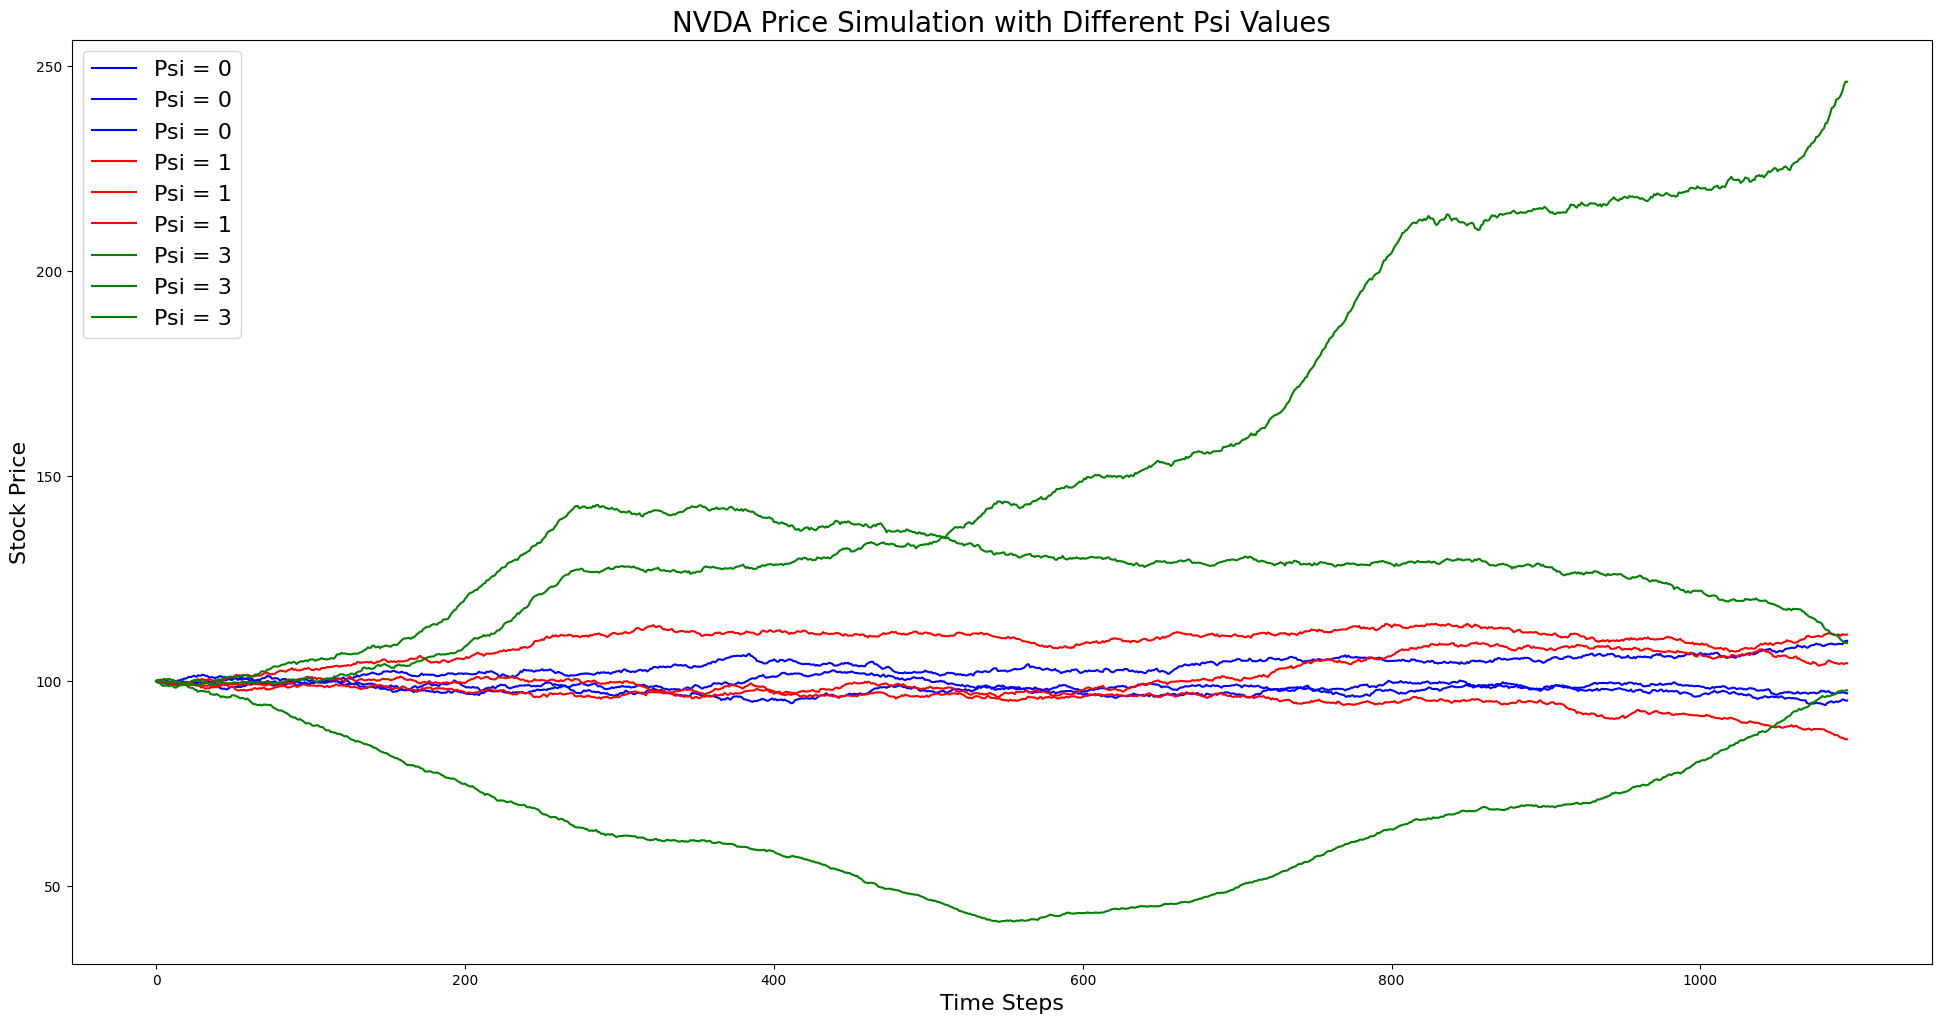

In [269]:
plt.subplots(figsize=(24,12))
plt.title('NVDA Price Simulation with Different Psi Values', fontsize=20)
plt.plot(S_NVDA_psi1.iloc[0], label='Psi = 0', color='blue')
plt.plot(S_NVDA_psi1.iloc[1], label='Psi = 0', color='blue')
plt.plot(S_NVDA_psi1.iloc[2], label='Psi = 0', color='blue')

plt.plot(S_NVDA_psi2.iloc[0], label='Psi = 1', color='red')
plt.plot(S_NVDA_psi2.iloc[1], label='Psi = 1', color='red')
plt.plot(S_NVDA_psi2.iloc[2], label='Psi = 1', color='red')

plt.plot(S_NVDA_psi3.iloc[0], label='Psi = 3', color='green')
plt.plot(S_NVDA_psi3.iloc[1], label='Psi = 3', color='green')
plt.plot(S_NVDA_psi3.iloc[2], label='Psi = 3', color='green')
plt.xlabel('Time Steps', fontsize=16)
plt.ylabel('Stock Price', fontsize=16)
plt.legend(fontsize=16) 


In [285]:
def get_quarterly_summary(results, opex_indices):
    
    stock_price = results['S']
    delta = results['delta']
    b = results['b']
    portfolio = results['portfolio']

    # Create a DataFrame to store the quarterly summary
    time = []
    Path_count = []
    S = []
    Delta = []
    Cash = []
    Portfolio_Value = []

    for t in opex_indices:
        for path in range(M):
            time.append(t)
            Path_count.append(path)
            S.append(stock_price.iloc[path, t])
            Delta.append(delta.iloc[path, t])
            Cash.append(b.iloc[path, t])
            Portfolio_Value.append(portfolio.iloc[path, t])

    df_summary = pd.DataFrame({
        'Time': time,
        'Path_count': Path_count,
        'S': S,
        'Delta': Delta,
        'Cash': Cash,
        'Portfolio_Value': Portfolio_Value
    })
    
    return df_summary


results_psi3 = simulate_full_paths(
    S0, b_0, sigma, psi=3, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
    dt=dt, N=N, M=M, opex_indices=opex_indices)


summary_df = get_quarterly_summary(results_psi3, opex_indices)
summary_df

,Time,Path_count,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000e+00,0.000000e+00
1,0,1,100.000000,0.000000,0.000000e+00,0.000000e+00
2,0,2,100.000000,0.000000,0.000000e+00,0.000000e+00
3,273,0,132.569157,0.815475,7.141411e+07,0.000000e+00
4,273,1,102.394197,0.820288,-3.762891e+01,0.000000e+00
5,273,2,149.584541,0.813389,1.265173e+08,0.000000e+00
6,546,0,103.587567,0.820273,7.142705e+07,0.000000e+00
7,546,1,68.128277,0.828083,2.056059e+04,0.000000e+00
8,546,2,195.097558,0.808815,1.265421e+08,0.000000e+00
9,819,0,127.157134,0.816247,7.143695e+07,0.000000e+00
